In [20]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [21]:
def nome (stringa):
    
    stringa_nuova = stringa.replace(f'./Data/dati_','').replace('.csv','')
    return stringa_nuova

In [22]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir(f'./Data'))]
data1 = {}

for input_file in input_files:
    letti = pd.read_csv(input_file)

    data1[nome(input_file)] = {
        "angoli": [np.array(letti["angolo"], dtype=float),
                   np.var(np.array(letti["angolo"], dtype=float))],
        "intensita": [np.array(letti["intensita"], dtype=float),
                      np.var(np.array(letti["intensita"], dtype=float))]
        }

Fit polarizzazione1
	a = -2566.44767 ± 0.00007 
	b = -15931.16455 ± 0.00006 
	c = 28267668.4967 ± 0.0001 

Fit polarizzazione2
	a = -2483.6068 ± 0.0001 
	b = 22931.98 ± 0.06 
	c = 26729457.1 ± 0.2 



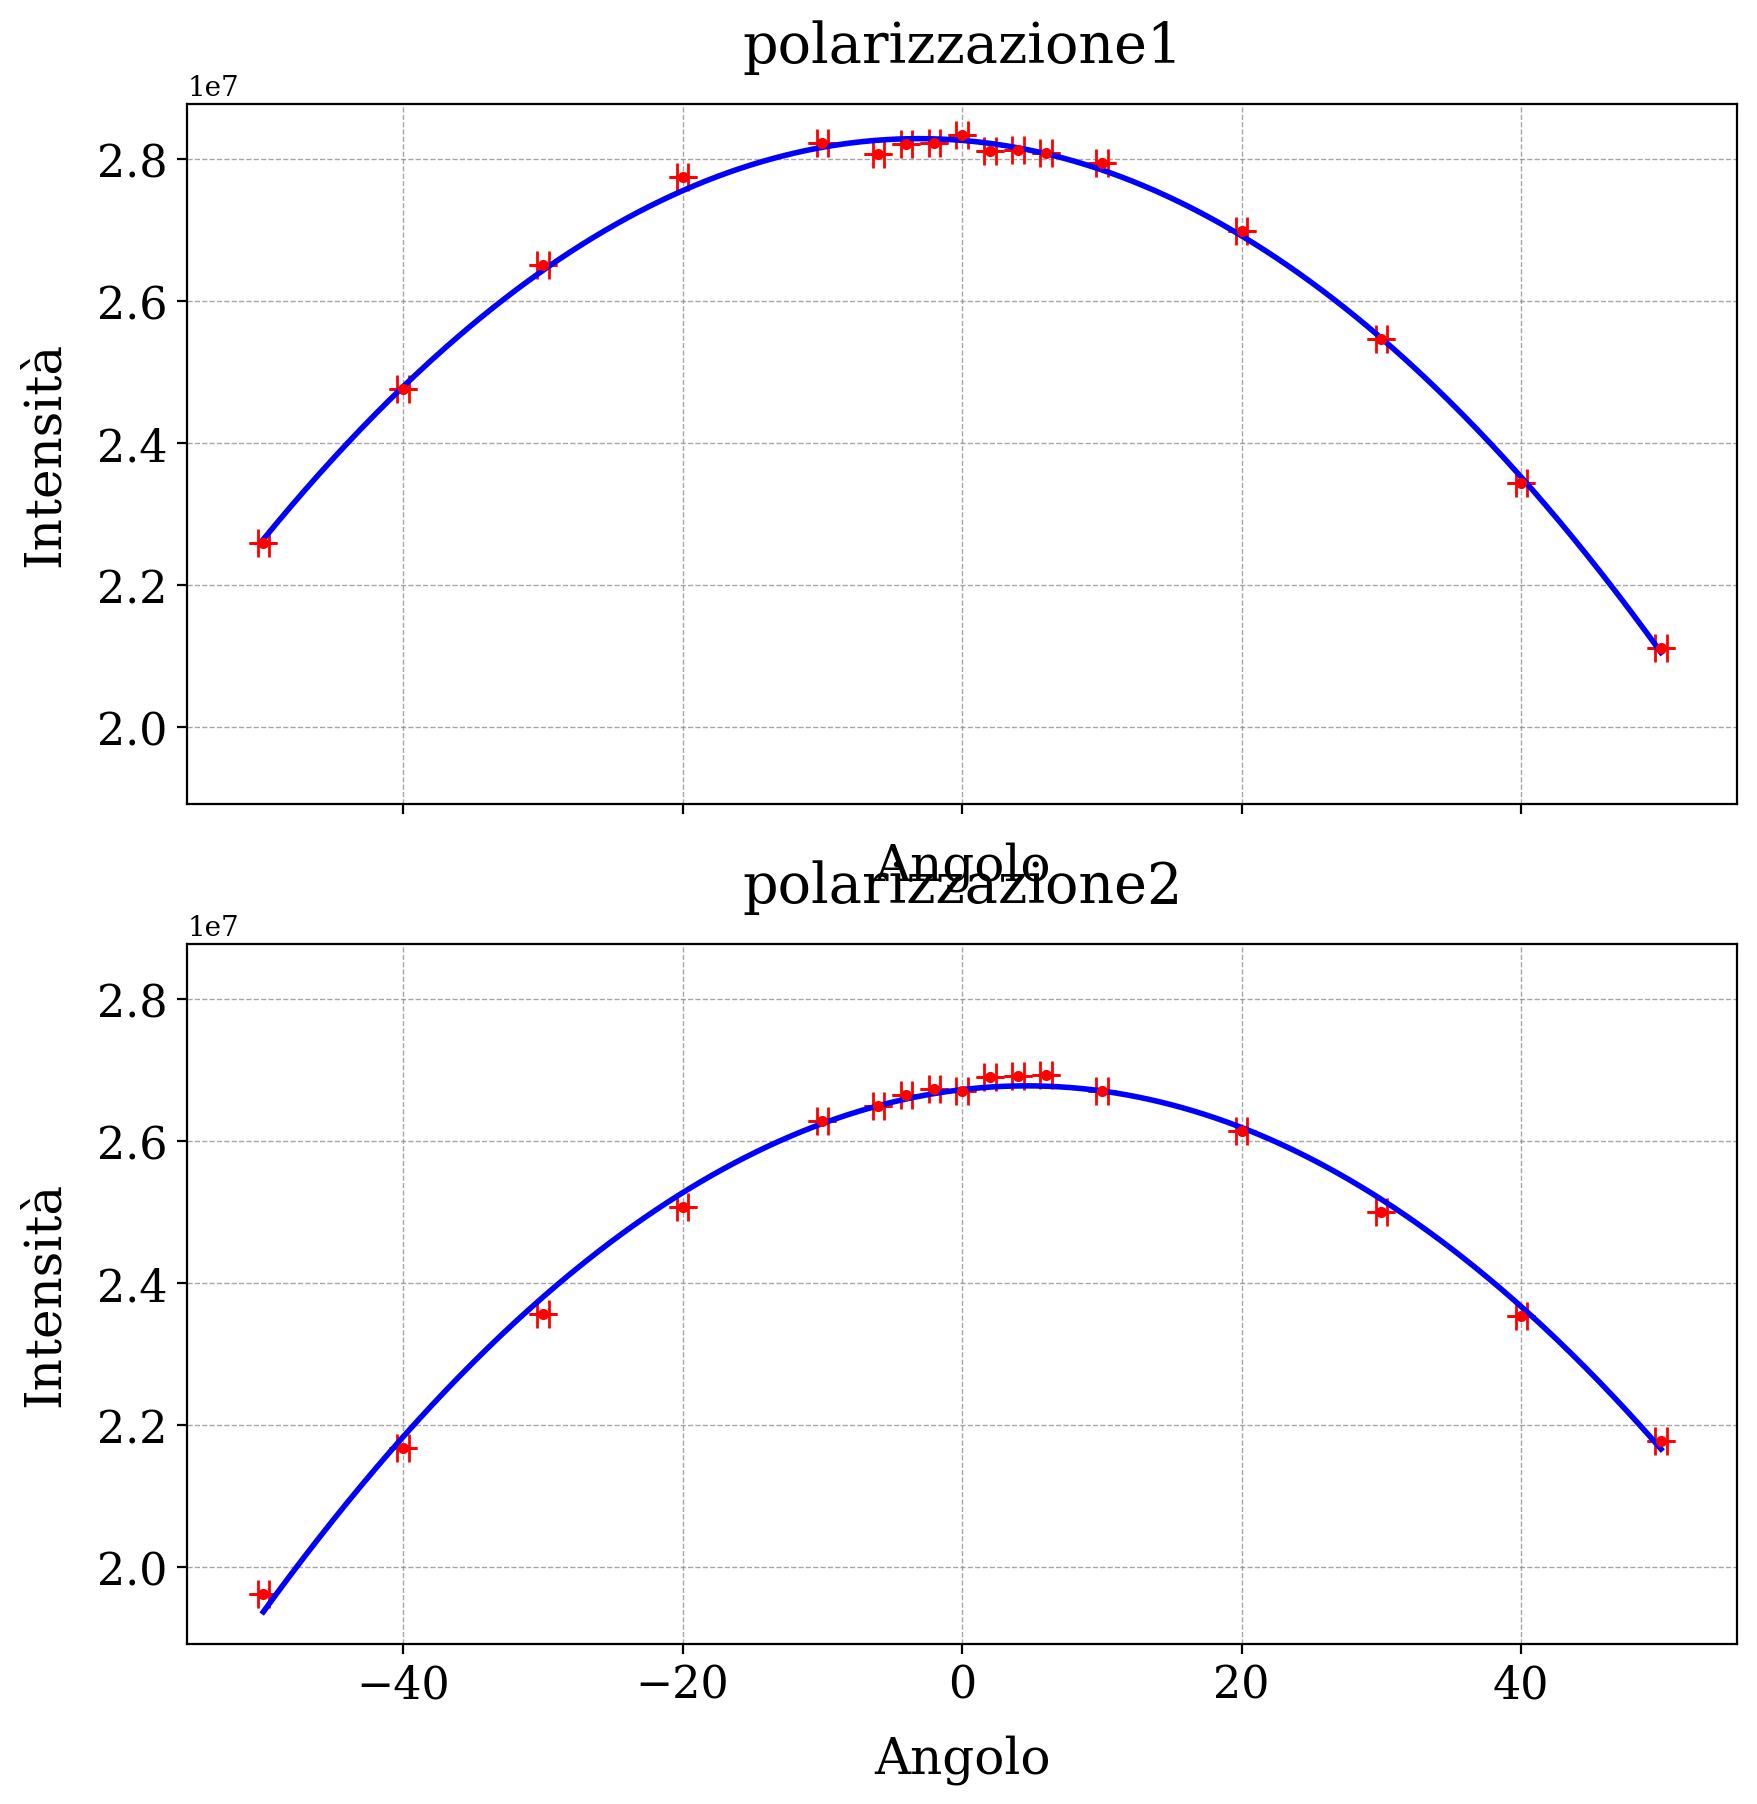

In [54]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharex=True, sharey=True)

for i,(titolo,dati) in enumerate(data1.items()):

    ax = axes[i]

    # Dati
    xdata = [dati["angoli"][0], np.full_like(dati["angoli"][0], 2/np.sqrt(24))]
    ydata = [dati["intensita"][0], np.full_like(dati["intensita"][0], 1/np.sqrt(12))]

    # Grafico dei dati
    gf.parametri_grafico(ax,titolo,xlabel="Angolo",ylabel="Intensità")
    ax.errorbar(xdata[0], ydata[0], xerr=xdata[1], yerr=ydata[1], color="red", fmt=".", **gf.default_error_params())

    """
    # Modello parabolico per fit con ODR
    def parabola(B, x):
        (a, b, c) = B
        return a*x**2 + b*x + c
    from scipy.odr import Model, RealData, ODR
    model = Model(parabola)
    data = RealData(xdata[0], ydata[0], sx=xdata[1], sy=ydata[1])
    odr = ODR(data, model, beta0=[-1000.0, 0.0, 1.0])
    output = odr.run()
    anal = [[output.beta[0], np.sqrt(abs(output.cov_beta[0][0]))],
            [output.beta[1], np.sqrt(abs(output.cov_beta[1][1]))],
            [output.beta[2], np.sqrt(abs(output.cov_beta[2][2]))]]
    """

    # Modello parabolico con fit Chi Quadro
    def chi2(B, x, y, sy):
        (a, b, c) = B
        return np.sum(((y - (a*x**2 + b*x + c)) / sy) ** 2)
    from scipy.optimize import minimize
    x = xdata[0]
    y = ydata[0]
    sy = ydata[1]
    B0 = [-1000.0, 0.0, 1.0]
    res = minimize(chi2, B0, args=(x, y, sy))
    anal = [[res.x[0], np.sqrt(abs(res.hess_inv[0][0]))],
            [res.x[1], np.sqrt(abs(res.hess_inv[1][1]))],
            [res.x[2], np.sqrt(abs(res.hess_inv[2][2]))]]

    print(f"Fit {titolo}")
    print(f"\ta = {gf.formatta_errore(anal[0][0],anal[0][1],txt=True)}")
    print(f"\tb = {gf.formatta_errore(anal[1][0],anal[1][1],txt=True)}")
    print(f"\tc = {gf.formatta_errore(anal[2][0],anal[2][1],txt=True)}\n")

    # Plot fit
    x = np.linspace(np.min(xdata), np.max(xdata), 500)
    y = parabola([anal[0][0], anal[1][0], anal[2][0]], x)
    ax.plot(x, y, color="blue")

    del xdata,ydata,x,y